# Ch 10-3 텍스트 생성하기

## 1. 디코더 기반의 대규모 언어 모델
## 2. EXAONE
EXAONE은 디코더 기반 트랜스포머 모델입니다. BART처럼 인코더의 출력을 전달받는 크로스 어텐션 층이 없다는 점을 유념
EXAONE은 최신 LLM에서 널리 사용하는 그룹 쿼리 어텐션grouped query attention을 사용합니다. 이는 
멀티 헤드 어텐션의 변형

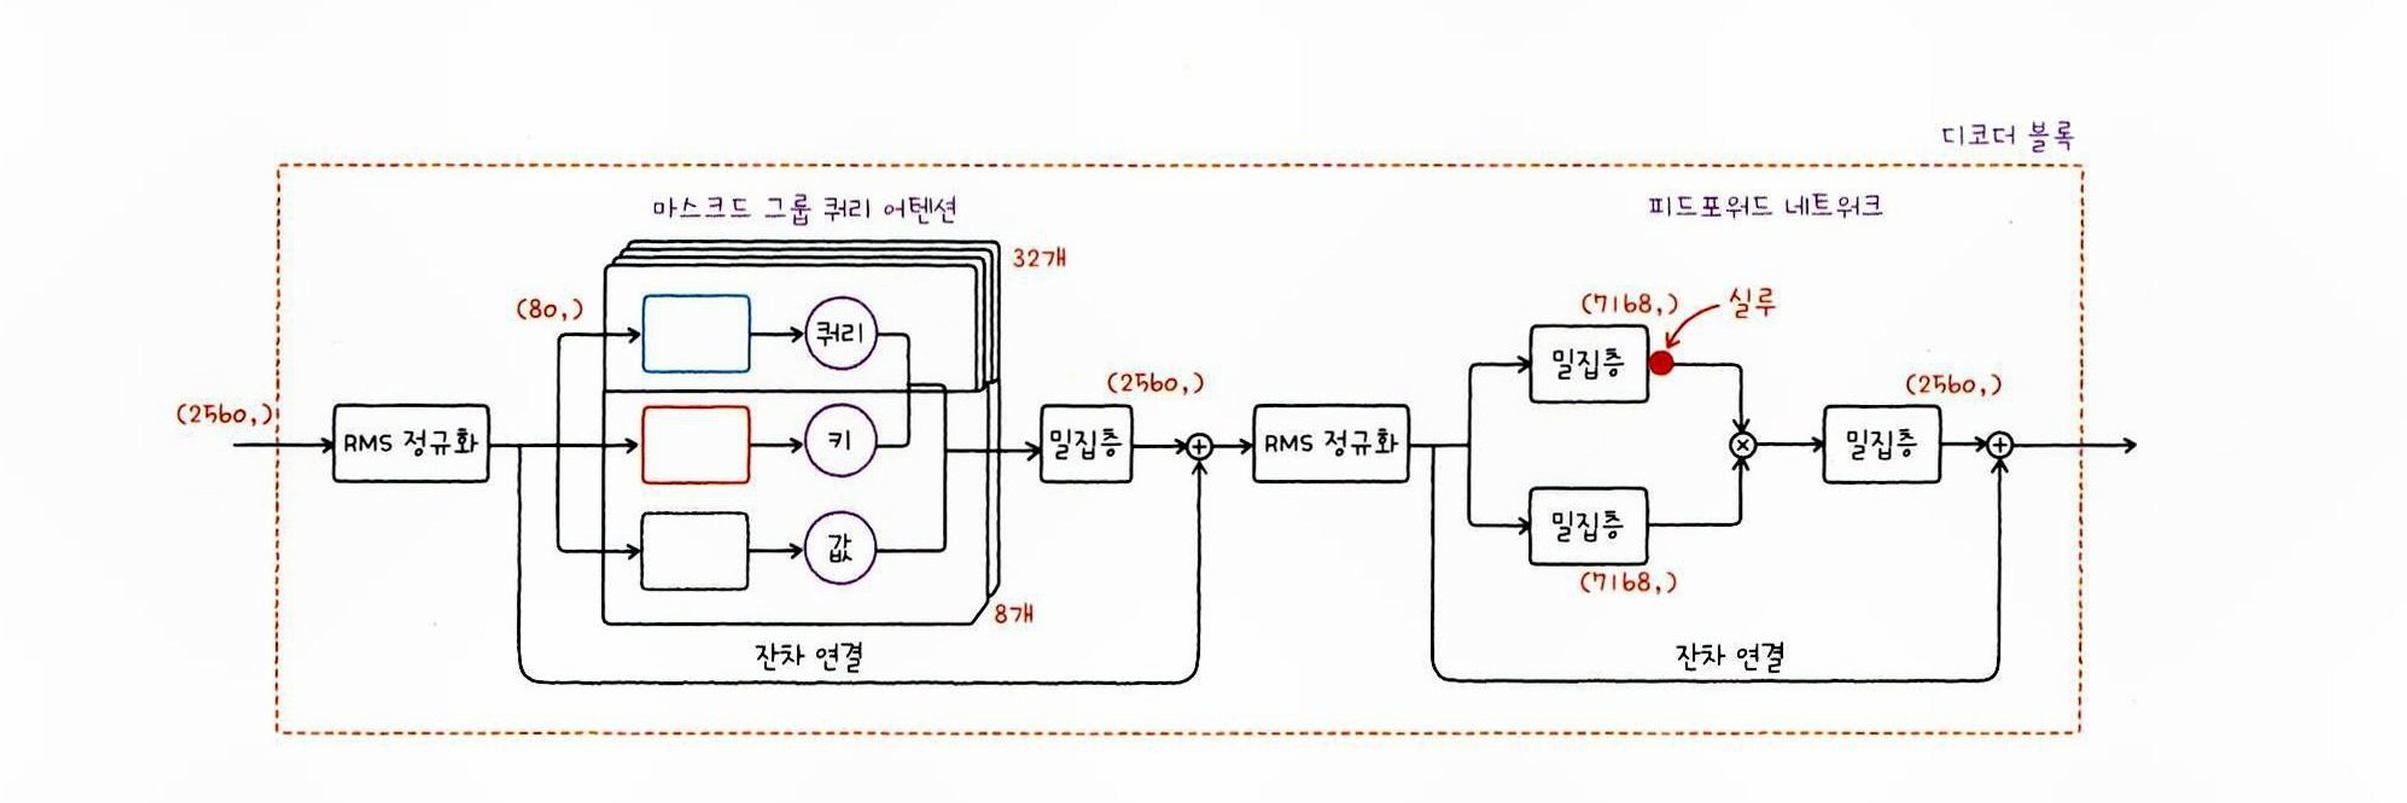

## 3. EXAONE-3.5로 상품 질문에 대한 대답 생성하기

채팅 탬플릿에 최적ㄱ화

In [1]:
from transformers import AutoTokenizer

exaone_tokenizer = AutoTokenizer.from_pretrained(
    "LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/563 [00:00<?, ?B/s]

In [2]:
from transformers import pipeline

pipe = pipeline(task="text-generation",
                model="LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct",
                tokenizer=exaone_tokenizer,
                device=0, trust_remote_code=True)

2025-12-10 11:42:07.841665: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-10 11:42:08.515101: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-10 11:42:12.090722: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


config.json: 0.00B [00:00, ?B/s]

configuration_exaone.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct:
- configuration_exaone.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_exaone.py: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/4.65G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Device set to use cuda:0


role = 대화 상대의 역할 
content = 실제 메시지 내용


In [3]:
messages = [
    {"role": "system",
     "content": "너는 쇼핑몰 홈페이지에 올라온 질문에 대답하는 Q&A 챗봇이야. \
                 확정적인 답변을 하지 말고 제품 담당자가 정확한 답변을 하기 위해 \
                 시간이 필요하다는 간단하고 친절한 답변을 생성해줘."},
    {"role": "user", "content": "이 다이어리에 내년도 공휴일이 표시되어 있나요?"}
]

pipe(messages, max_new_tokens=200)

[{'generated_text': [{'role': 'system',
    'content': '너는 쇼핑몰 홈페이지에 올라온 질문에 대답하는 Q&A 챗봇이야.                  확정적인 답변을 하지 말고 제품 담당자가 정확한 답변을 하기 위해                  시간이 필요하다는 간단하고 친절한 답변을 생성해줘.'},
   {'role': 'user', 'content': '이 다이어리에 내년도 공휴일이 표시되어 있나요?'},
   {'role': 'assistant',
    'content': '안녕하세요! 다이어리에 내년의 공휴일 정보가 포함되어 있는지 확인해 드리려고 노력하고 있지만, 현재 바로 답을 드리기 어렵습니다. 제품 담당자분께서 가장 정확한 정보를 제공해 드릴 수 있을 것 같아요. 그분께 문의하시면 바로 답변을 드릴 수 있을 것입니다. 감사합니다! 😊'}]}]

생성된 텍스트는 딕셔너리의 리스트 형태로 반환

In [4]:
#모델이 생성한 텍스트만 출력
pipe(messages, max_new_tokens=500, return_full_text=False)

[{'generated_text': '안녕하세요! 다이어리에 대한 질문 감사합니다. 현재로선 정확한 답변을 드리기 어렵습니다. 공휴일 정보는 매년 정부에서 공식적으로 발표하므로, 다이어리가 제작된 시점에 따라 포함 여부가 달라질 수 있어요. 혹시 제품 출시일이 궁금하시다면 알려주시면 더 자세한 정보를 찾아볼 수 있을 것 같습니다. 제품 담당자분께서 확인해 주시고 바로 답변드릴 수 있도록 연락 주시면 감사하겠습니다!'}]

In [5]:
output = pipe(messages, max_new_tokens=200, return_full_text=False,
              do_sample=True)
print(output[0]['generated_text'])

안녕하세요! 다이어리에 내년의 공휴일 정보가 포함되어 있는지에 대해 자세히 알려드릴 수는 없지만, 일반적으로 고급 다이어리나 전문가용 제품들은 종종 최신 정보를 반영하도록 설계되어 있어요. 하지만 정확한 답변을 위해서는 제품 담당자분께 문의하시는 것이 가장 좋을 것 같아요. 담당자분께서는 현재 제품의 업데이트 상태와 공휴일 정보 포함 여부를 확인해 주실 수 있을 거예요. 감사합니다!


# 토큰 디코딩 전략

디코더가 출력하는 값은 확률이 아니라 실제로는 각 토큰에 대한 점수를 말함.   
이 점수에 소프트 맥스 함수를 적용하면 확률로 변환 할 수 있고, 그 전의 값을 **로짓_logit**이라고 부름        

디코더가 출력한 로짓 중에서 어떤 토큰ㅇ르 선택할 지는 LLM모델이 아니라 TRANSFORMERS 같은딥러닝 프레임워크의 몫.     

### Transformers 
가장 간단한 디코딩 방식은 **do_sample** 메게 변수가 default값 False 일때.
= 가장 높은 확률을 가진 토큰 하나를 선택    
여러 번 실행해도 항상 같은 대답을 얻을 수 있어서 **Greedy Search**라고 부름

In [9]:
import numpy as np 

logits = np.array([1, 2, 3, 4, 100])

In [10]:
#softmax 함수 통과시키기
from scipy.special import softmax

probas = softmax(logits)
print(probas)

[1.01122149e-43 2.74878501e-43 7.47197234e-43 2.03109266e-42
 1.00000000e+00]


In [11]:
np.random.multinomial(100, probas)

array([  0,   0,   0,   0, 100])

100번 모두 마지막 원소가 선택됨         
그러면, 그리디 서치를 적용하는 것과 별반 다를 게 없음.      

따라서, 소프트 맥스 함수가 만드는 확률분포를 조금 변형시켜주는 기법을 사용

In [12]:
probas = softmax(logits/100)
np.random.multinomial(100, probas)

array([14, 15, 21,  8, 42])

logit을 1보다 큰 값으로 나누면 확률 분포가 조금 더 부드러워져 다른 원소가 선택될 가능성이 높아지고,     
1보다 작은 값으로 나누면 확률 분포가 더 결정적으로 ㅂ바뀌어 가장 큰 로짓을 선택하는 그리디 서치와 비슷하게 동작         

이를 **Temperature**이라고 함


In [14]:
output = pipe(messages, max_new_tokens=200, return_full_text=False,
                          do_sample=True, temperature=10.0)
print(output[0]['generated_text'])

아andr로 질문하시나 본 점 양해 부탁드려요: 감사 합니다만 자세な답변이나 정보 변경에 상관없이 보장 드릴 순 CurrentlyAvailable Product Details 페이지 상의 Holiday AnnotatisOn들으기 어려우셔 바로 제공가능 합니다요.- 직접 해당제품 문의 메일처하시게 만들어질수록 제일 fastest 및 clearresponse받으니, 쇼핑몰 홈 혹은 연락방법 부분 찾아봐봐요.- 귀하 요청에는 공휴일 내역사항 외에 많을까하는데 만약 제품 정보변동일론 부분 관심이나, 추가유인물라든지 정확내용 알곤파셨거나 바로관련해서 더욱도움제공도 드려져욤! 편하도록요 연락처 보내주십니다! 언제든지 저희 연락 취해나오시오! 빠르면서도 명료하니 빠른 정보 주시어요 😭‍�med•한


In [15]:
output = pipe(messages, max_new_tokens=200, return_full_text=False,
                          do_sample=True, temperature=0.001                                 )
print(output[0]['generated_text'])

안녕하세요! 다이어리에 내년의 공휴일이 미리 표시되어 있는지에 대해 정확한 답변을 드리기 위해서는 제품 담당자에게 확인이 필요합니다. 현재로선 직접 확인이 어려우니, 저희가 안내드릴 수 있는 방법으로는 고객센터에 연락하시거나, 제품 페이지 내의 문의 게시판을 통해 질문해 보시는 것이 좋을 것 같습니다. 담당자분께서 빠르게 답변해 주실 거예요! 감사합니다.


### Top K 샘플링
모델이 출력한 로짓을 기준으로 최상위 k개의 토큰을 선택하는 방법.
이후 선택된 토큰의 로짓만 소프트 맥스 함수에 통과시킴

In [16]:
output = pipe(messages, max_new_tokens=200, return_full_text=False,
                          do_sample=True, top_k=10                             )
print(output[0]['generated_text'])

안녕하세요! 다이어리에 내년도 공휴일이 표시되어 있는지 확인해드리려면, 제품 담당자께서 직접 확인 후 알려드릴 수 있어요. 현재로선 정확한 정보를 제공하기 어렵지만, 저희 팀은 가능한 한 빨리 답변을 드리기 위해 노력하고 있습니다. 궁금한 점이 더 있으시다면 언제든지 다시 물어봐 주세요! 😊


transformers 패키지는 temperature을 top-k나 top-p보다 먼저 적용하므로       
로짓 -> temperature 로 분포 조정 -> top_k만큼 최상위 k개 로짓 선택 -> 소프트맥스 함수 적용

In [20]:
output = pipe(messages, max_new_tokens=200, return_full_text=False,
                          do_sample=True, top_k=10 , temperature=10.0           )
print(output[0]['generated_text'])

아하하~ 그런 질문 잘 받아들이니까요~! 제품 설명서를 잘 훑어보세요~~ 혹시 바로 답변 드릴게요~! ㅈ ㅠ

정확하길 원하니까 시간 내서 확인하고 알려 드릴게유~ 공휴일 내용들이 다 정리될 때까지 좀 기다려 주세요 😅 곧 좋은 정보 드릴 거 같네용~ 😊 

즐거운 휴일들을 계획해 놓으시는 동안 이 질문에도 빨리 대답드릴 기회 만들어드릴 게유~ 😉💼☕! 궁금한 점이 다시 생겨주시겠죠? 👋 🥀  ̂ ̄̈̂


### Top-P샘플링
최상위 토큰의 개수를 고정하는 게 아니라 확률 순으로 토큰을 나열 후 사전에 지정한 확률만큼만 최상위 토큰을 선택하는 방식.
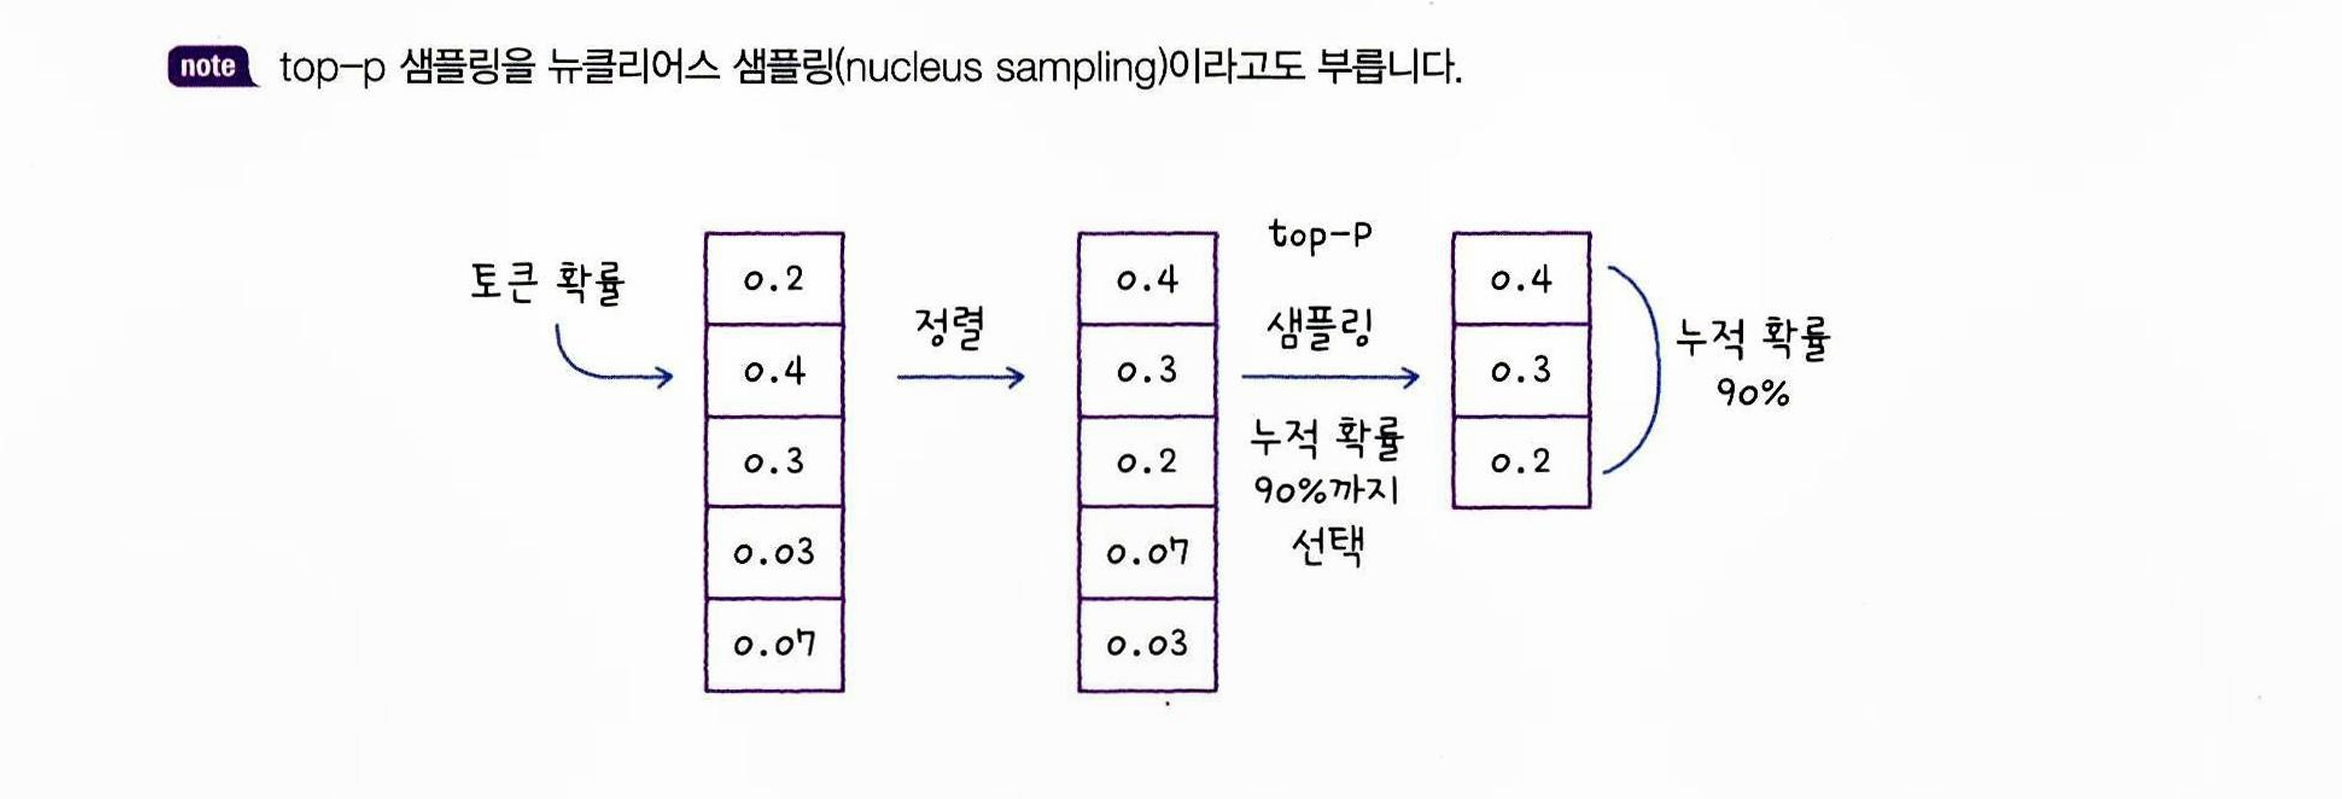

일반적으로 0.9 ~ 0.95 사이의 값을 사용

In [21]:
output = pipe(messages, max_new_tokens=200, return_full_text=False,
                          do_sample=True, top_p =0.9          )
print(output[0]['generated_text'])

안녕하세요! 다이어리에 내년의 모든 공휴일이 정확하게 표시되어 있는지 확인해 드리려면 현재 사용 가능한 정보가 제한적입니다. 정확한 답변을 위해서는 제품 담당자님께 문의하시는 것이 가장 좋을 것 같아요. 담당자분께서 최신 공휴일 정보를 반영하여 제작되었는지 확인하실 수 있을 거예요. 혹시 궁금하신 점이 더 있으시다면 알려주세요!


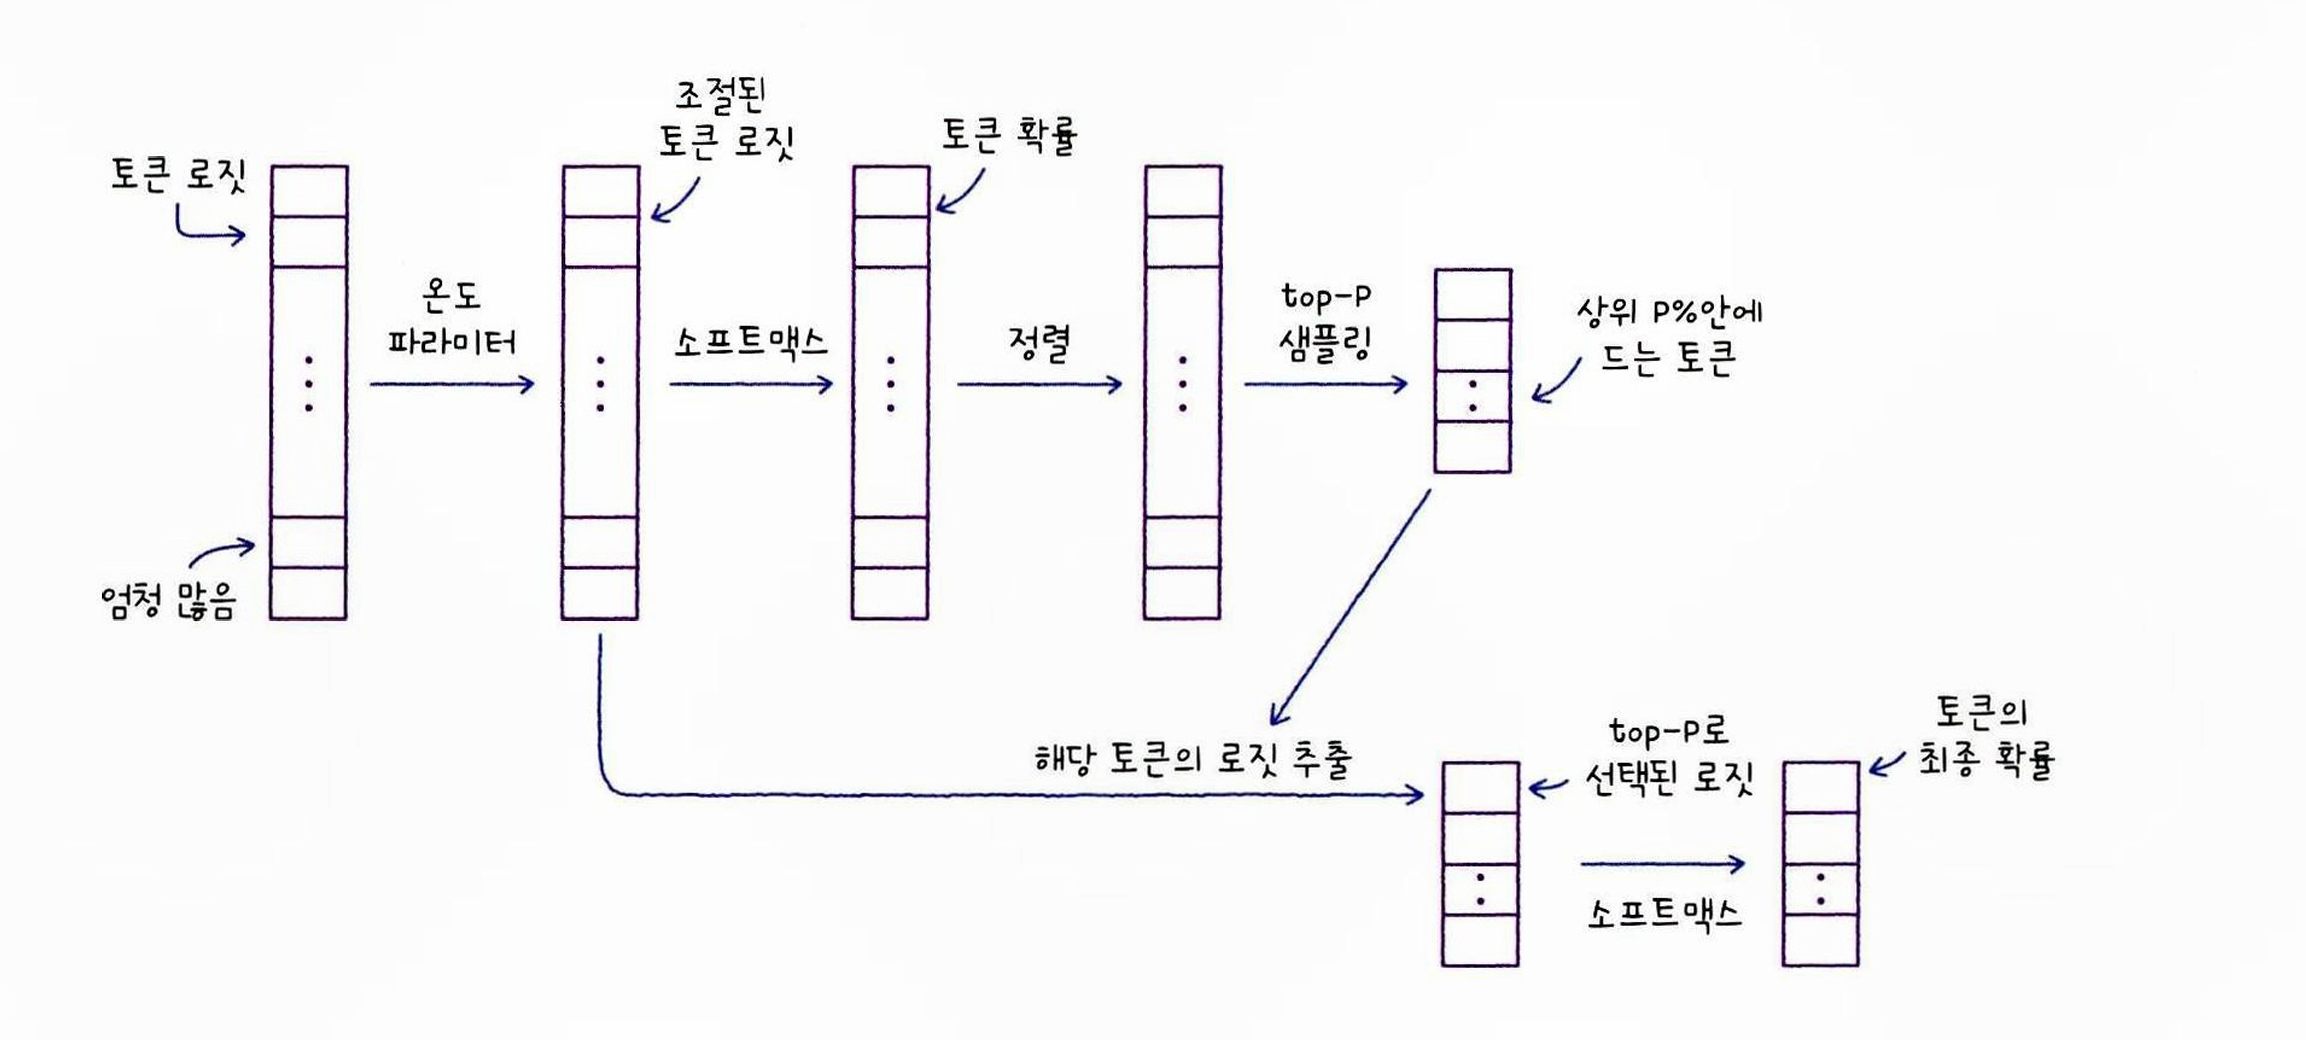

그러나 이렇게 되면 전체 로짓 토큰에 소프트맥스 함수를 적용할 때 계산이 많이 들 것 같음      
그래서, top-k와 top-p를 모두 사용하는 방식이 좋음       
top-k로 최상위 로짓을 일부 선택 -> top-p 방식 적용

In [24]:
output = pipe(messages, max_new_tokens=200, return_full_text=False,
              do_sample=True, temperature=0.8, top_k=100, top_p=0.9)
print(output[0]['generated_text'])

안녕하세요!  다이어리의 공휴일 표시 여부에 대해 궁금하시군요. 정확한 답변을 드리기 위해서는 제품 담당자께 문의하시는 게 가장 좋을 것 같아요.  제품 담당자께서는 다이어리의 정확한 사양과 제작일 등을 알려주실 수 있으니, 그 분께 연락하시면 답변을 빨리 받으실 수 있을 거예요. 감사합니다! 😊


# 3. open ai

In [26]:
from openai import OpenAI

In [ ]:
client = OpenAI(api_key="s")

In [28]:
completion = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=messages
)

In [29]:
print(completion.choices[0].message.content)

안녕하세요! 질문 주셔서 감사합니다. 다이어리에 내년도 공휴일이 표시되어 있는지 확인하려면 시간이 필요합니다. 제품 담당자가 빠르게 확인할 수 있도록 하겠습니다. 조금만 기다려 주시기 바랍니다!


In [30]:
completion = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=messages,
    top_p=0.9
)
print(completion.choices[0].message.content)

안녕하세요! 해당 다이어리에 내년도 공휴일이 표시되어 있는지 확인해보도록 하겠습니다. 제품 담당자가 정확한 정보를 제공해 드릴 수 있도록 조금만 기다려 주세요. 감사합니다!


In [31]:
completion = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=messages,
    temperature=1.8
)
print(completion.choices[0].message.content)

안녕하세요! 고객님, 문의해주셔서 감사합니다. 해당 다이어리에 내년도 공휴일이 표시되어 있는지에 대한 정보는 제품 담당자가 확인 후 정확하게 안내해드릴 수 있습니다. 조금만 시간 드리겠습니다. 감사합니다!
